In [1]:
import spacy
import pandas as pd
import numpy as np

nlp = spacy.load("it_core_news_md")

### Generazione delle silver labels 
- Non abbiamo a disposizione delle etichette di complessità, quindi una strategia è quella di evidenziare le parole che sono state cancellate o sostituite nella frase semplice.

##### Vecchie funzioni di prova

In [7]:
def silver_labels_set(original: str, simplification: str):
    """
    SET-BASED: token di d evidenziato (1) se il suo LEMMA non compare tra i lemmi di d'
    (a prescindere dalla posizione). Metodo più semplice ma meno preciso: una parola presente ma spostata risulta 'tenuta', e i duplicati vengono sottostimati.
    Ritorna (tokens, labels).
    """
    doc_o = nlp(original)
    simp_lemmas = {t.lemma_.lower() for t in nlp(simplification) if not t.is_space}
    tokens, labels = [], []
    for t in doc_o:
        if t.is_space:
            continue
        tokens.append(t.text)
        labels.append(int(t.lemma_.lower() not in simp_lemmas))
    return tokens, labels

In [8]:
## Esempio di SequenceMatcher 
from difflib import SequenceMatcher
a = "qabxcd"
b = "abycdf"
s = SequenceMatcher(None, a, b)
for tag, i1, i2, j1, j2 in s.get_opcodes():
    print('{:7}   a[{}:{}] --> b[{}:{}] {!r:>8} --> {!r}'.format(
        tag, i1, i2, j1, j2, a[i1:i2], b[j1:j2]))

delete    a[0:1] --> b[0:0]      'q' --> ''
equal     a[1:3] --> b[0:2]     'ab' --> 'ab'
replace   a[3:4] --> b[2:3]      'x' --> 'y'
equal     a[4:6] --> b[3:5]     'cd' --> 'cd'
insert    a[6:6] --> b[5:6]       '' --> 'f'


In [9]:
def silver_labels_tipate(original: str, simplification: str):


    """ Qui si usa SequenceMatcher per confrontare le due sequenze di lemmi e generare etichette più precise, distinguendo tra cancellazioni e sostituzioni."""

    doc_o = [t for t in nlp(original) if not t.is_space]
    lem_o = [t.lemma_.lower() for t in doc_o]
    lem_s = [t.lemma_.lower() for t in nlp(simplification) if not t.is_space]

    tipo = ["keep"] * len(doc_o)                    # keep | del | sub

    for tag, i1, i2, j1, j2 in SequenceMatcher(a=lem_o, b=lem_s, autojunk=False).get_opcodes():
        if tag == "delete":
            for i in range(i1, i2): tipo[i] = "del"   # cancellazione  
        elif tag == "replace":
            for i in range(i1, i2): tipo[i] = "sub"   # sostituzione 

    tokens = [t.text for t in doc_o]
    labels = [int(x != "keep") for x in tipo]         # 1 = complesso (del o sub)

    return tokens, labels, tipo

In [11]:
test = pd.read_parquet("/code/HLTproject_code/data/test.parquet")
#test.head(5) df con text e is_original (True/False) per distinguere frasi complesse e semplificate

orig = (test[test["is_original"]]
        .drop_duplicates("original_sentence_idx")
        .set_index("original_sentence_idx")["text"])

simp = (test[~test["is_original"]]
        .drop_duplicates("original_sentence_idx")   # 1 semplificazione per originale (K=1)
        .set_index("original_sentence_idx")["text"])

pairs = (pd.concat([orig.rename("original"), simp.rename("simplification")], axis=1)
           .dropna().reset_index())
print(f"Coppie di valutazione (frasi complesse del test): {len(pairs)}")
pairs.head()

Coppie di valutazione (frasi complesse del test): 7539


,original_sentence_idx,original,simplification
0,10,"Prodotto dalla BBC, il film esce solo nel 1998...","Nel 1998, il film è stato rilasciato e ha rice..."
1,20,"ad aprile per la fiera del bestiame, a giugno ...","aprile per la fiera del bestiame, giugno per l..."
2,22,La popolarità e il prestigio di Marco Antonio ...,Questo fatto non ha influenzato la popolarità ...
3,42,Pur di riconquistare la ex ragazza Elaine ora ...,"Per riconquistare Elaine, Striker ha preso un ..."
4,80,"Cabrera firmò, all'età di 17 anni, con i New Y...","All'età di 17 anni, firmò con i New York Yankees"


In [12]:
## prova di evidenziazione dei token complessi (con funzione set base) nelle prime due coppie di valutazione

from IPython.display import HTML, display
def show_html(tokens, labels):
    display(HTML(" ".join(
        f'<span style="background:#f8b">{t}</span>' if l else t
        for t, l in zip(tokens, labels))))
    
for _, row in pairs.head(2).iterrows():
    toks, labs = silver_labels_set(row["original"], row["simplification"])
    print("ORIGINALE   :", row["original"])
    print("SEMPLIFICATA:", row["simplification"])
    print("EVIDENZIATO :", show_html(toks, labs))
    print(f"({sum(labs)}/{len(labs)} token evidenziati)\n")

ORIGINALE   : Prodotto dalla BBC, il film esce solo nel 1998 ed ottiene numerosi riconoscimenti internazionali, tra cui la candidatura al Premio Oscar per il miglior cortometraggio animato.
SEMPLIFICATA: Nel 1998, il film è stato rilasciato e ha ricevuto numerosi riconoscimenti internazionali, tra cui la nomination all'Academy Award for Best Animated Short Film.


EVIDENZIATO : None
(13/29 token evidenziati)

ORIGINALE   : ad aprile per la fiera del bestiame, a giugno per la compravendita del grano, a settembre per i festeggiamenti del santo patrono, con i fuochi pirotecnici e con delle corse ippiche che richiamavano dai paesi circostanti una moltitudine di gente.
SEMPLIFICATA: aprile per la fiera del bestiame, giugno per la vendita di grano, settembre per i festeggiamenti del santo patrono con fuochi d'artificio e corse ippiche


EVIDENZIATO : None
(14/44 token evidenziati)



In [36]:
## prova di evidenziazione dei token complessi (con funzione tipata) nelle prime due coppie di valutazione

from IPython.display import HTML, display

COLORI = {"del": "#f8b", "sub": "#bdf"}   # del = rosa, sub = azzurro

def show_html(tokens, tipo):
    spans = []
    for t, tp in zip(tokens, tipo):
        c = COLORI.get(tp)
        spans.append(f'<span style="background:{c}">{t}</span>' if c else t)
    display(HTML(" ".join(spans)))

for _, row in pairs.head(5).iterrows():
    toks, labs, tipo = silver_labels_tipate(row["original"], row["simplification"])   # versione tipata
    print("ORIGINALE   :", row["original"])
    print("SEMPLIFICATA:", row["simplification"])
    show_html(toks, tipo)                                                      
    n_del = sum(x == "del" for x in tipo)
    n_sub = sum(x == "sub" for x in tipo)
    print(f"(cancellazioni: {n_del} · sostituzioni: {n_sub} · su {len(toks)} token)\n")

ORIGINALE   : Prodotto dalla BBC, il film esce solo nel 1998 ed ottiene numerosi riconoscimenti internazionali, tra cui la candidatura al Premio Oscar per il miglior cortometraggio animato.
SEMPLIFICATA: Nel 1998, il film è stato rilasciato e ha ricevuto numerosi riconoscimenti internazionali, tra cui la nomination all'Academy Award for Best Animated Short Film.


(cancellazioni: 0 · sostituzioni: 16 · su 29 token)

ORIGINALE   : ad aprile per la fiera del bestiame, a giugno per la compravendita del grano, a settembre per i festeggiamenti del santo patrono, con i fuochi pirotecnici e con delle corse ippiche che richiamavano dai paesi circostanti una moltitudine di gente.
SEMPLIFICATA: aprile per la fiera del bestiame, giugno per la vendita di grano, settembre per i festeggiamenti del santo patrono con fuochi d'artificio e corse ippiche


(cancellazioni: 17 · sostituzioni: 3 · su 44 token)

ORIGINALE   : La popolarità e il prestigio di Marco Antonio peraltro non soffrirono a causa di questo fatto;
SEMPLIFICATA: Questo fatto non ha influenzato la popolarità e la reputazione di Marco Antonio.


(cancellazioni: 0 · sostituzioni: 10 · su 17 token)

ORIGINALE   : Pur di riconquistare la ex ragazza Elaine ora impiegata come hostess, Striker decide di trovare il coraggio, imbarcandosi in un volo per Chicago dove ella presta servizio.
SEMPLIFICATA: Per riconquistare Elaine, Striker ha preso un volo a Chicago.


(cancellazioni: 11 · sostituzioni: 11 · su 30 token)

ORIGINALE   : Cabrera firmò, all'età di 17 anni, con i New York Yankees il 13 novembre 2001, con un bonus alla firma di 175.000 dollari.
SEMPLIFICATA: All'età di 17 anni, firmò con i New York Yankees


(cancellazioni: 17 · sostituzioni: 0 · su 28 token)



#### Costruzione coppie di valutazione (frasi complesse e semplificate del test set)

In [24]:
test = pd.read_parquet("/code/HLTproject_code/data/test.parquet")
#test.head(5) df con text e is_original (True/False) per distinguere frasi complesse e semplificate

orig = (test[test["is_original"]]
        .drop_duplicates("original_sentence_idx")
        .set_index("original_sentence_idx")["text"])

simp = (test[~test["is_original"]]
        .drop_duplicates("original_sentence_idx")   # 1 semplificazione per originale (K=1)
        .set_index("original_sentence_idx")["text"])

pairs = (pd.concat([orig.rename("original"), simp.rename("simplification")], axis=1)
           .dropna().reset_index())
print(f"Coppie di valutazione (frasi complesse del test): {len(pairs)}")
pairs.head()

Coppie di valutazione (frasi complesse del test): 7539


,original_sentence_idx,original,simplification
0,10,"Prodotto dalla BBC, il film esce solo nel 1998...","Nel 1998, il film è stato rilasciato e ha rice..."
1,20,"ad aprile per la fiera del bestiame, a giugno ...","aprile per la fiera del bestiame, giugno per l..."
2,22,La popolarità e il prestigio di Marco Antonio ...,Questo fatto non ha influenzato la popolarità ...
3,42,Pur di riconquistare la ex ragazza Elaine ora ...,"Per riconquistare Elaine, Striker ha preso un ..."
4,80,"Cabrera firmò, all'età di 17 anni, con i New Y...","All'età di 17 anni, firmò con i New York Yankees"


In [25]:
import unicodedata
from difflib import SequenceMatcher

# richiede: nlp (spaCy italiano) già caricato nel notebook/script

def _norm(s):
    """Normalizza per il confronto: minuscolo, senza accenti, senza apostrofi."""
    s = s.lower().strip()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))   # toglie accenti
    s = s.replace("'", "").replace("’", "").replace("`", "")
    return s

def _similar(a, b, thr=0.80):
    """True se due token sono quasi-uguali (variante ortografica, non vera modifica)."""
    na, nb = _norm(a), _norm(b)
    if na == nb:
        return True
    # uno contiene l'altro (es. 'panamericani' vs 'panamericani' splittato)
    if na in nb or nb in na:
        return True
    return SequenceMatcher(None, na, nb).ratio() >= thr


def silver_labels(original, simplification,
                     mode="both",          # "both" = del+sub ; "sub_only" = solo sostituzioni
                     ignore_expansions=True,
                     guard_false_del=True):
    """
    Etichette silver migliorate da una coppia (originale, semplificata).

    Migliorie rispetto alla versione base:
    - confronto su lemmi normalizzati (niente falsi 'sub' per accenti/apostrofi/maiuscole);
    - dentro i blocchi 'replace', i token che hanno una controparte quasi-identica
      nel testo semplificato restano 'keep' (varianti ortografiche, non semplificazioni);
    - le espansioni (semplificata più lunga che aggiunge materiale) non generano 'sub' spuri;
    - guardia anti falso-'del': se il token compare ancora (normalizzato) nella semplificata,
      probabilmente è un disallineamento del matcher -> 'keep';
    - mode='sub_only' per marcare solo le sostituzioni lessicali (segnale più pulito).

    Ritorna: tokens (list[str]), labels (list[int 0/1]), tipo (list["keep"|"del"|"sub"]).
    """
    doc_o = [t for t in nlp(original) if not t.is_space]
    doc_s = [t for t in nlp(simplification) if not t.is_space]

    tok_o = [t.text for t in doc_o]
    lem_o = [t.lemma_.lower() for t in doc_o]
    lem_s = [t.lemma_.lower() for t in doc_s]
    txt_o = tok_o
    txt_s = [t.text for t in doc_s]

    # insieme normalizzato dei token semplificati
    norm_s_set = {_norm(w) for w in txt_s}

    tipo = ["keep"] * len(doc_o)

    sm = SequenceMatcher(a=lem_o, b=lem_s, autojunk=False)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():

        if tag == "delete":
            # cancellazione pura: marca, ma con guardia anti-disallineamento
            for i in range(i1, i2):
                if guard_false_del and _norm(txt_o[i]) in norm_s_set:
                    continue                      # il token c'è ancora altrove -> keep
                tipo[i] = "del"

        elif tag == "replace":
            span_b = txt_s[j1:j2]                  # token semplificati corrispondenti

            # espansione: il blocco semplificato è molto più lungo dell'originale
            # => è materiale aggiunto, non una sostituzione di ciò che c'era
            if ignore_expansions and len(span_b) > 2 * max(1, (i2 - i1)):
                # tratta come keep salvo i token che spariscono del tutto
                for i in range(i1, i2):
                    if _norm(txt_o[i]) not in norm_s_set and not any(
                            _similar(txt_o[i], b) for b in span_b):
                        tipo[i] = "del"
                continue

            for i in range(i1, i2):
                # variante ortografica? il token ha un quasi-gemello nel blocco b -> keep
                if any(_similar(txt_o[i], b) for b in span_b):
                    continue
                # token ancora presente identico altrove nella semplificata -> keep
                if guard_false_del and _norm(txt_o[i]) in norm_s_set:
                    continue
                tipo[i] = "sub"

    # applica il mode
    if mode == "sub_only":
        labels = [int(x == "sub") for x in tipo]
    else:  # both
        labels = [int(x != "keep") for x in tipo]

    return txt_o, labels, tipo

In [26]:
## prova di evidenziazione dei token complessi nelle prime due coppie di valutazione

from IPython.display import HTML, display

COLORI = {"del": "#f8b", "sub": "#bdf"}   # del = rosa, sub = azzurro

def show_html(tokens, tipo):
    spans = []
    for t, tp in zip(tokens, tipo):
        c = COLORI.get(tp)
        spans.append(f'<span style="background:{c}">{t}</span>' if c else t)
    display(HTML(" ".join(spans)))

for _, row in pairs.head(4).iterrows():
    toks, labs, tipo = silver_labels(row["original"], row["simplification"])   # versione tipata
    print("ORIGINALE   :", row["original"])
    print("SEMPLIFICATA:", row["simplification"])
    show_html(toks, tipo)                                                      
    n_del = sum(x == "del" for x in tipo)
    n_sub = sum(x == "sub" for x in tipo)
    print(f"(cancellazioni: {n_del} · sostituzioni: {n_sub} · su {len(toks)} token)\n")

## il risultato non é perfetto però ci può stare

ORIGINALE   : Prodotto dalla BBC, il film esce solo nel 1998 ed ottiene numerosi riconoscimenti internazionali, tra cui la candidatura al Premio Oscar per il miglior cortometraggio animato.
SEMPLIFICATA: Nel 1998, il film è stato rilasciato e ha ricevuto numerosi riconoscimenti internazionali, tra cui la nomination all'Academy Award for Best Animated Short Film.


(cancellazioni: 0 · sostituzioni: 11 · su 29 token)

ORIGINALE   : ad aprile per la fiera del bestiame, a giugno per la compravendita del grano, a settembre per i festeggiamenti del santo patrono, con i fuochi pirotecnici e con delle corse ippiche che richiamavano dai paesi circostanti una moltitudine di gente.
SEMPLIFICATA: aprile per la fiera del bestiame, giugno per la vendita di grano, settembre per i festeggiamenti del santo patrono con fuochi d'artificio e corse ippiche


(cancellazioni: 13 · sostituzioni: 1 · su 44 token)

ORIGINALE   : La popolarità e il prestigio di Marco Antonio peraltro non soffrirono a causa di questo fatto;
SEMPLIFICATA: Questo fatto non ha influenzato la popolarità e la reputazione di Marco Antonio.


(cancellazioni: 0 · sostituzioni: 6 · su 17 token)

ORIGINALE   : Pur di riconquistare la ex ragazza Elaine ora impiegata come hostess, Striker decide di trovare il coraggio, imbarcandosi in un volo per Chicago dove ella presta servizio.
SEMPLIFICATA: Per riconquistare Elaine, Striker ha preso un volo a Chicago.


(cancellazioni: 11 · sostituzioni: 9 · su 30 token)



In [27]:
eval_set = []
for _, row in pairs.iterrows():
    doc_o = [t for t in nlp(row["original"]) if not t.is_space]
    tokens, labels, tipo = silver_labels(row["original"], row["simplification"])
    eval_set.append({
        "original":  row["original"] ,
        "idx": row["original_sentence_idx"],
        "tokens": tokens,
        "lemmas": [t.lemma_.lower() for t in doc_o],
        "pos":    [t.pos_ for t in doc_o],
        "silver": labels, "tipo": tipo,
        "simp_tokens": [t.text for t in nlp(row["simplification"]) if not t.is_space],
    })

In [28]:
eval_set_df = pd.DataFrame(eval_set)
eval_set_df.head(5)

,original,idx,tokens,lemmas,pos,silver,tipo,simp_tokens
0,"Prodotto dalla BBC, il film esce solo nel 1998...",10,"[Prodotto, dalla, BBC, ,, il, film, esce, solo...","[prodotto, da il, bbc, ,, il, film, uscire, so...","[VERB, ADP, PROPN, PUNCT, DET, NOUN, VERB, ADV...","[1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, ...","[sub, sub, sub, keep, keep, keep, keep, sub, k...","[Nel, 1998, ,, il, film, è, stato, rilasciato,..."
1,"ad aprile per la fiera del bestiame, a giugno ...",20,"[ad, aprile, per, la, fiera, del, bestiame, ,,...","[a, aprile, per, il, fiera, di il, bestiame, ,...","[ADP, NOUN, ADP, DET, NOUN, ADP, NOUN, PUNCT, ...","[1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[del, keep, keep, keep, keep, keep, keep, keep...","[aprile, per, la, fiera, del, bestiame, ,, giu..."
2,La popolarità e il prestigio di Marco Antonio ...,22,"[La, popolarità, e, il, prestigio, di, Marco, ...","[il, popolarità, e, il, prestigio, di, marco, ...","[DET, NOUN, CCONJ, DET, NOUN, ADP, PROPN, PROP...","[0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, ...","[keep, keep, keep, keep, sub, keep, keep, keep...","[Questo, fatto, non, ha, influenzato, la, popo..."
3,Pur di riconquistare la ex ragazza Elaine ora ...,42,"[Pur, di, riconquistare, la, ex, ragazza, Elai...","[pure, di, riconquistare, il, ex, ragazza, ela...","[ADV, ADP, VERB, DET, ADJ, NOUN, PROPN, ADV, V...","[1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, ...","[sub, sub, keep, del, del, del, keep, del, del...","[Per, riconquistare, Elaine, ,, Striker, ha, p..."
4,"Cabrera firmò, all'età di 17 anni, con i New Y...",80,"[Cabrera, firmò, ,, all', età, di, 17, anni, ,...","[cabrera, firmare, ,, a il, età, di, 17, anno,...","[PROPN, VERB, PUNCT, ADP, NOUN, ADP, NUM, NOUN...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[del, keep, keep, keep, keep, keep, keep, keep...","[All', età, di, 17, anni, ,, firmò, con, i, Ne..."


In [29]:
len(eval_set_df), len(eval_set_df["silver"])            

(7539, 7539)

In [30]:
## save eval set

import pickle

with open("eval_set_full.pkl", "wb") as f:
    pickle.dump(eval_set, f)

#### Valutazione

In [8]:
from nltk.metrics import edit_distance
s1 = "ciao a tutti!"
s2 = "ciao a tutteeeee, come va?!"  

## ritorna un punteggio numerico che indica il numero minimo di operazioni (inserimenti, cancellazioni, sostituzioni) necessarie per trasformare s1 in s2. 
# lavora a livello di carattere, a noi ci serve word-level

score = edit_distance(s1, s2, substitution_cost=1, transpositions=False)
print(f"Edit distance tra '{s1}' e '{s2}': {score}")

Edit distance tra 'ciao a tutti!' e 'ciao a tutteeeee, come va?!': 15


In [ ]:
# def word_edit_distance(a, b, sub_cost=1.0):

#     """Levenshtein a livello di parola"""
    
#     n, m = len(a), len(b)
#     dp = [[0.0]*(m+1) for _ in range(n+1)]
#     for i in range(n+1): dp[i][0] = i
#     for j in range(m+1): dp[0][j] = j
#     for i in range(1, n+1):
#         for j in range(1, m+1):
#             if a[i-1] == b[j-1]:
#                 dp[i][j] = dp[i-1][j-1]
#             else:
#                 dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+sub_cost)
#     return dp[n][m]

In [10]:
def word_edit_distance(words_a, words_b, sub_cost=1.0):
    """
    Calcola la distanza di Levenshtein a livello di parola.

    words_a e words_b devono essere liste di parole, ad esempio:
        ["ciao", "come", "stai"]

    Operazioni considerate:
    - inserimento di una parola: costo 1
    - cancellazione di una parola: costo 1
    - sostituzione di una parola: costo sub_cost   

    Restituisce il costo minimo per trasformare words_a in words_b.
    """

    len_a = len(words_a)
    len_b = len(words_b)

    # dp[i][j] rappresenta il costo minimo per trasformare
    # le prime i parole di words_a nelle prime j parole di words_b
    dp = [[0.0 for _ in range(len_b + 1)] for _ in range(len_a + 1)]

    # Caso base:
    # trasformare le prime i parole di words_a in una lista vuota
    # richiede i cancellazioni
    for i in range(len_a + 1):
        dp[i][0] = i

    # Caso base:
    # trasformare una lista vuota nelle prime j parole di words_b
    # richiede j inserimenti
    for j in range(len_b + 1):
        dp[0][j] = j

    # Riempimento della matrice dinamica
    for i in range(1, len_a + 1):
        for j in range(1, len_b + 1):

            current_word_a = words_a[i - 1]
            current_word_b = words_b[j - 1]

            if current_word_a == current_word_b:
                # Le parole sono uguali: nessun costo aggiuntivo
                dp[i][j] = dp[i - 1][j - 1]
            else:
                deletion = dp[i - 1][j] + 1
                insertion = dp[i][j - 1] + 1
                substitution = dp[i - 1][j - 1] + sub_cost

                dp[i][j] = min(deletion, insertion, substitution)

    return dp[len_a][len_b]

In [11]:
score = word_edit_distance(s1.split(), s2.split(), sub_cost=1.0)
print(f"Edit distance tra '{s1}' e '{s2}': {score}")

Edit distance tra 'ciao a tutti!' e 'ciao a tutteeeee, come va?!': 3.0


In [ ]:
# ## metriche di valutazione (precision, recall, F1, edit distance, TER) per un insieme di predizioni binarie allineate a eval_set_df["tokens"]

# import numpy as np
# from sklearn.metrics import precision_recall_fscore_support
# from sacrebleu.metrics import TER

# _ter = TER()

# def word_edit_distance(a, b, sub_cost=1.0):

#     """Levenshtein a livello di parola"""
    
#     n, m = len(a), len(b)
#     dp = [[0.0]*(m+1) for _ in range(n+1)]
#     for i in range(n+1): dp[i][0] = i
#     for j in range(m+1): dp[0][j] = j
#     for i in range(1, n+1):
#         for j in range(1, m+1):
#             if a[i-1] == b[j-1]:
#                 dp[i][j] = dp[i-1][j-1]
#             else:
#                 dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+sub_cost)
#     return dp[n][m]

# def evaluate(eval_set, preds):

#     """preds[i] = vettore binario allineato a eval_set[i]['tokens']."""
#     P, R, F1, ED1, ED15, ED2, TERs = ([] for _ in range(7))
#     for ex, pred in zip(eval_set, preds):
#         y, p = ex["silver"], list(pred)
#         pr, rc, f1, _ = precision_recall_fscore_support(
#             y, p, average="binary", pos_label=1, zero_division=0)
#         P.append(pr); R.append(rc); F1.append(f1)

#         # parte NON evidenziata di d  vs  d'
#         kept    = [t for t, pl in zip(ex["tokens"], p) if pl == 0]
#         d_prime = ex["simp_tokens"]
#         ED1.append( word_edit_distance(kept, d_prime, 1.0))
#         ED15.append(word_edit_distance(kept, d_prime, 1.5))
#         ED2.append( word_edit_distance(kept, d_prime, 2.0))
#         TERs.append(_ter.sentence_score(" ".join(kept), [" ".join(d_prime)]).score)

#     return {
        
#         "precision": float(np.mean(P)),  "recall": float(np.mean(R)),
#         "f1": float(np.mean(F1)),
#         "ed_sub1":  float(np.mean(ED1)), "ed_sub1.5": float(np.mean(ED15)),
#         "ed_sub2":  float(np.mean(ED2)), "ter": float(np.mean(TERs)),
#     }

In [12]:
## metriche di valutazione (precision, recall, F1, edit distance, TER)
## per predizioni binarie allineate a eval_set[i]["tokens"] con alcuni check aggiuntivi

import numpy as np
from sklearn.metrics import precision_recall_fscore_support
from sacrebleu.metrics import TER

_ter = TER()

def word_edit_distance(a, b, sub_cost=1.0):
    """Levenshtein a livello di parola"""
    n, m = len(a), len(b)
    dp = [[0.0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): dp[i][0] = i
    for j in range(m+1): dp[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            if a[i-1] == b[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+sub_cost)
    return dp[n][m]


def check_alignment(eval_set, preds, verbose=True, max_show=10):
    """
    Verifica che, per ogni frase, len(tokens) == len(silver) == len(pred).
    Ritorna la lista degli indici disallineati. NON modifica i dati.
    """
    bad = []
    for i, (ex, pred) in enumerate(zip(eval_set, preds)):
        n_tok = len(ex["tokens"])
        n_sil = len(ex["silver"])
        n_prd = len(pred)
        if not (n_tok == n_sil == n_prd):
            bad.append((i, n_tok, n_sil, n_prd))

    if len(preds) != len(eval_set):
        print(f"!! ATTENZIONE: {len(preds)} predizioni ma {len(eval_set)} frasi nel set")

    if verbose:
        if not bad:
            print(f"OK: tutte {len(eval_set)} le frasi sono allineate "
                  f"(tokens == silver == pred).")
        else:
            print(f"!! DISALLINEAMENTO in {len(bad)}/{len(eval_set)} frasi.")
            print("   idx | len(tokens) len(silver) len(pred)")
            for row in bad[:max_show]:
                i, nt, ns, npd = row
                flag_sil = "" if nt == ns else "  <- silver != tokens"
                flag_prd = "" if nt == npd else "  <- pred != tokens"
                print(f"   {i:4d} |   {nt:4d}      {ns:4d}     {npd:4d}{flag_sil}{flag_prd}")
            if len(bad) > max_show:
                print(f"   ... e altre {len(bad)-max_show} frasi")
            print("\n   -> Finché c'è disallineamento, precision/recall/F1 non sono "
                  "affidabili:\n      si confrontano posizioni di token diverse.")
    return bad


def evaluate(eval_set, preds, strict=True):
    """
    preds[i] = vettore binario allineato a eval_set[i]['tokens'].
    Se strict=True, interrompe quando trova frasi disallineate.
    """
    bad = check_alignment(eval_set, preds)
    if bad and strict:
        raise ValueError(
            f"{len(bad)} frasi disallineate: correggi l'allineamento prima di "
            f"calcolare le metriche, oppure passa strict=False per saltarle.")

    P, R, F1, ED1, ED15, ED2, TERs = ([] for _ in range(7))
    skipped = 0
    for ex, pred in zip(eval_set, preds):
        p = list(pred)
        y = ex["silver"]

        # salta le frasi disallineate (solo se strict=False)
        if len(y) != len(p) or len(p) != len(ex["tokens"]):
            skipped += 1
            continue

        pr, rc, f1, _ = precision_recall_fscore_support(
            y, p, average="binary", pos_label=1, zero_division=0)
        P.append(pr); R.append(rc); F1.append(f1)

        # parte NON evidenziata di d  vs  d'
        kept    = [t for t, pl in zip(ex["tokens"], p) if pl == 0]
        d_prime = ex["simp_tokens"]
        ED1.append( word_edit_distance(kept, d_prime, 1.0))
        ED15.append(word_edit_distance(kept, d_prime, 1.5))
        ED2.append( word_edit_distance(kept, d_prime, 2.0))
        TERs.append(_ter.sentence_score(" ".join(kept), [" ".join(d_prime)]).score)

    if skipped:
        print(f"(saltate {skipped} frasi disallineate nel calcolo)")

    return {
        "precision": float(np.mean(P)),  "recall": float(np.mean(R)),
        "f1": float(np.mean(F1)),
        "ed_sub1":  float(np.mean(ED1)), "ed_sub1.5": float(np.mean(ED15)),
        "ed_sub2":  float(np.mean(ED2)), "ter": float(np.mean(TERs)),
        "n_valutate": len(P),
    }

In [14]:
##carico set di valutazione

import pickle 

with open("eval_set_full.pkl", "rb") as f:
        eval_set = pickle.load(f)

In [15]:
##baseline random 

rng = np.random.default_rng(42)

def predict_random(eval_set, rate=0.3):
    preds = []
    for ex in eval_set:
        n = len(ex["tokens"])
        k = int(round(rate * n))
        idx = rng.choice(n, size=min(k, n), replace=False)
        p = [0]*n
        for i in idx: p[i] = 1
        preds.append(p)
    return preds

preds = predict_random(eval_set)

In [16]:
print("RANDOM:", evaluate(eval_set, predict_random(eval_set)))

OK: tutte 7539 le frasi sono allineate (tokens == silver == pred).


RANDOM: {'precision': 0.3392449878812878, 'recall': 0.28783684796660935, 'f1': 0.2831066353678992, 'ed_sub1': 19.831807932086484, 'ed_sub1.5': 22.913582703276298, 'ed_sub2': 25.38280939116594, 'ter': 82.4819090545292, 'n_valutate': 7539}


In [17]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

def evaluate_tipato(eval_set, preds):
    """
    Valuta gli highlight separatamente su cancellazioni (del) e sostituzioni (sub).
    Per ogni vista: i positivi sono SOLO i token di quel tipo; gli altri tipi
    complessi vengono ESCLUSI dal conteggio (non sono ne' positivi ne' rumore).
    """
    out = {}
    for target in ("del", "sub"):
        Ps, Rs, F1s = [], [], []
        for ex, pred in zip(eval_set, preds):
            # tieni i token che sono 'keep' (negativi) o del tipo target (positivi);
            # scarta i token dell'altro tipo per non confondere la misura
            keep = [i for i, tp in enumerate(ex["tipo"]) if tp in ("keep", target)]
            if not keep:
                continue
            y = [int(ex["tipo"][i] == target) for i in keep]
            p = [int(pred[i]) for i in keep]
            if sum(y) == 0:            # nessun positivo di questo tipo in questa frase
                continue
            pr, rc, f1, _ = precision_recall_fscore_support(
                y, p, average="binary", pos_label=1, zero_division=0)
            Ps.append(pr); Rs.append(rc); F1s.append(f1)
        out[target] = {"precision": float(np.mean(Ps)),
                       "recall":    float(np.mean(Rs)),
                       "f1":        float(np.mean(F1s)),
                       "n_frasi":   len(F1s)}
    return out

In [18]:
for nome, preds in [("RANDOM", preds)]:
    r = evaluate_tipato(eval_set, preds)
    print(f"{nome:7} | DEL  P/R/F1: {r['del']['precision']:.2f}/{r['del']['recall']:.2f}/{r['del']['f1']:.2f}"
          f"   SUB  P/R/F1: {r['sub']['precision']:.2f}/{r['sub']['recall']:.2f}/{r['sub']['f1']:.2f}")

RANDOM  | DEL  P/R/F1: 0.28/0.30/0.25   SUB  P/R/F1: 0.24/0.30/0.23


#### Valutazione features

In [82]:
meta = {"original_sentence_idx", "text", "score", "is_original"}

feat_cols = [c for c in test.columns if c not in meta]

of = (test[test["is_original"]].drop_duplicates("original_sentence_idx")
        .set_index("original_sentence_idx")[feat_cols])
sf = (test[~test["is_original"]].drop_duplicates("original_sentence_idx")
        .set_index("original_sentence_idx")[feat_cols])

In [83]:
of.head(3)

,n_sentences,n_tokens,tokens_per_sent,char_per_tok,in_dict,in_dict_types,in_FO,in_AD,in_AU,in_FO_types,...,subordinate_pre,subordinate_post,verb_edges_dist_3,verb_edges_dist_0,verb_edges_dist_5,verb_edges_dist_1,verb_edges_dist_2,verb_edges_dist_6,verb_edges_dist_4,avg_verb_edges
original_sentence_idx,,,,,,,,,,,,,,,,,,,,,
10,1,32,32.0,5.103448,0.827586,0.791667,0.689655,0.034483,0.103448,0.625000,...,100.0,0.0,0.0,0.0,0.0,33.333333,33.333333,0.0,33.333333,2.333333
20,1,49,49.0,4.533333,0.822222,0.714286,0.577778,0.133333,0.111111,0.535714,...,0.0,100.0,100.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,3.000000
22,1,17,17.0,4.875000,0.875000,0.857143,0.437500,0.250000,0.187500,0.428571,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,100.000000,4.000000


In [84]:
sf.head(3)

,n_sentences,n_tokens,tokens_per_sent,char_per_tok,in_dict,in_dict_types,in_FO,in_AD,in_AU,in_FO_types,...,subordinate_pre,subordinate_post,verb_edges_dist_3,verb_edges_dist_0,verb_edges_dist_5,verb_edges_dist_1,verb_edges_dist_2,verb_edges_dist_6,verb_edges_dist_4,avg_verb_edges
original_sentence_idx,,,,,,,,,,,,,,,,,,,,,
16652,1,20,20.0,4.611111,0.388889,0.388889,0.333333,0.000000,0.055556,0.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,4.0
57104,1,10,10.0,3.900000,0.500000,0.444444,0.300000,0.200000,0.000000,0.222222,...,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,1.0
106741,1,18,18.0,4.235294,0.705882,0.615385,0.411765,0.117647,0.176471,0.307692,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,4.0


In [85]:
delta   = (of - sf).dropna()                       # quanto cala ogni feature
delta_z = (delta - delta.mean()) / delta.std(ddof=0)   # confrontabili tra feature di scala diversa

idx = pairs.iloc[6]["original_sentence_idx"]
print("Dimensioni di complessità ridotte di più in questa frase:")
print(delta_z.loc[idx].sort_values(ascending=False).head(5))

Dimensioni di complessità ridotte di più in questa frase:
dep_dist_appos     6.905062
subj_pre           2.402393
dep_dist_nsubj     1.606938
upos_dist_PROPN    1.112697
lexical_density    1.085028
Name: 120, dtype: float64


In [86]:
mean_orig = of.mean()
mean_simp = sf.mean()

In [87]:
import matplotlib.pyplot as plt

## valore medio per feature 
mean_orig = of.mean()
mean_simp = sf.mean()

df_feat = pd.DataFrame({
    "originale":    mean_orig,
    "semplificata": mean_simp,
})


In [88]:
df_feat

,originale,semplificata
n_sentences,1.000000,1.000000
n_tokens,32.975726,20.825441
tokens_per_sent,32.975726,20.825441
char_per_tok,4.745121,4.733636
in_dict,0.784384,0.777992
...,...,...
verb_edges_dist_1,12.991566,8.416562
verb_edges_dist_2,21.628983,24.717186
verb_edges_dist_6,2.392496,0.787392
verb_edges_dist_4,19.433792,16.256499


In [89]:
df_feat["delta"] = df_feat["originale"] - df_feat["semplificata"]
df_feat["delta"].head(10)

n_sentences         0.000000
n_tokens           12.150285
tokens_per_sent    12.150285
char_per_tok        0.011485
in_dict             0.006393
in_dict_types      -0.006949
in_FO              -0.007249
in_AD               0.005110
in_AU               0.008532
in_FO_types        -0.008559
Name: delta, dtype: float64

In [90]:
df_feat

,originale,semplificata,delta
n_sentences,1.000000,1.000000,0.000000
n_tokens,32.975726,20.825441,12.150285
tokens_per_sent,32.975726,20.825441,12.150285
char_per_tok,4.745121,4.733636,0.011485
in_dict,0.784384,0.777992,0.006393
...,...,...,...
verb_edges_dist_1,12.991566,8.416562,4.575003
verb_edges_dist_2,21.628983,24.717186,-3.088203
verb_edges_dist_6,2.392496,0.787392,1.605103
verb_edges_dist_4,19.433792,16.256499,3.177293


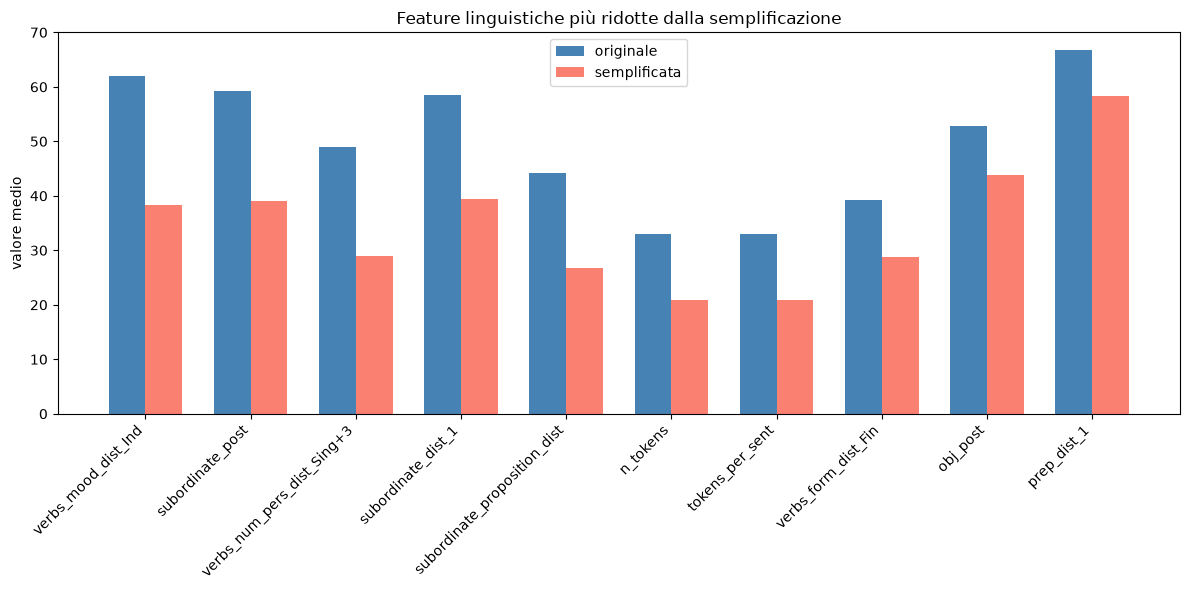

In [91]:
top = df_feat.sort_values("delta", ascending=False).head(10)
x = range(len(top))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar([i - width/2 for i in x], top["originale"], width, label="originale", color="steelblue")
ax.bar([i + width/2 for i in x], top["semplificata"], width, label="semplificata", color="salmon")
ax.set_xticks(list(x))
ax.set_xticklabels(top.index, rotation=45, ha="right")
ax.set_ylabel("valore medio")
ax.legend()
ax.set_title("Feature linguistiche più ridotte dalla semplificazione")
plt.tight_layout()
plt.show()

In [92]:
SUB_DEPS = {"advcl", "acl", "acl:relcl", "ccomp", "xcomp", "csubj"}

def spiega_span(doc, indici, vdb):
    
    span = [doc[i] for i in indici]
    motivi = []
    if any(t.dep_ in SUB_DEPS for t in span):
        motivi.append("clausola subordinata/participiale")
    if any(t.dep_ in {"aux:pass", "nsubj:pass"} for t in span):
        motivi.append("costruzione passiva")
    rare = [t.text for t in span if t.lemma_.lower() not in vdb]
    if rare:
        motivi.append("parole non di base: " + ", ".join(rare))
    return motivi or ["motivo non chiaro"]

#### Baseline lessicale

In [19]:
def carica_vdb(path):
    
    vdb = set()
    with open(path, encoding="utf-8") as f:
        for line in f:
            w = line.strip().split("\t")[0].split(",")[0].lower()  # adatta al formato
            if w and not w.startswith("#"):
                vdb.add(w)
    return vdb

vdb = carica_vdb("/code/HLTproject_code/nvdb/nvdb.words.txt")
print(f"VdB: {len(vdb)} lemmi")

VdB: 7181 lemmi


In [20]:
CONTENT = {"NOUN", "VERB", "ADJ", "ADV"}

def predict_vdb(eval_set, vdb):
    """Evidenzia le parole di contenuto il cui lemma NON e' nel Vocabolario di Base."""
    preds = []
    for ex in eval_set:
        p = [int(pos in CONTENT and lem not in vdb)
             for lem, pos in zip(ex["lemmas"], ex["pos"])]
        preds.append(p)
    return preds

In [21]:
preds_vdb = predict_vdb(eval_set, vdb)
print("VdB:", evaluate(eval_set, preds_vdb))
print(evaluate_tipato(eval_set, preds_vdb))   # vista del/sub

OK: tutte 7539 le frasi sono allineate (tokens == silver == pred).
VdB: {'precision': 0.34707637431824595, 'recall': 0.09551484730732325, 'f1': 0.12897762061594398, 'ed_sub1': 20.015784586815226, 'ed_sub1.5': 22.961467038068708, 'ed_sub2': 25.413582703276298, 'ter': 87.9427388456653, 'n_valutate': 7539}
{'del': {'precision': 0.2673664401460166, 'recall': 0.09216442038487996, 'f1': 0.11197945425247434, 'n_frasi': 5714}, 'sub': {'precision': 0.2584260093789372, 'recall': 0.11058391686588882, 'f1': 0.12759220879456523, 'n_frasi': 5301}}


In [22]:
len(vdb)

7181

In [23]:
preds_vdb = predict_vdb(eval_set, vdb)
rate_vdb = np.mean([np.mean(p) for p in preds_vdb])
print("frazione media evidenziata dal VdB:", rate_vdb)  

frazione media evidenziata dal VdB: 0.0800421159832209


In [ ]:
# for nome, preds in [("VDB", preds_vdb)]:
#     r = evaluate_tipato(eval_set, preds)
#     print(f"{nome:7} | DEL  P/R/F1: {r['del']['precision']:.2f}/{r['del']['recall']:.2f}/{r['del']['f1']:.2f}"
#           f"   SUB  P/R/F1: {r['sub']['precision']:.2f}/{r['sub']['recall']:.2f}/{r['sub']['f1']:.2f}")

#### Risultati explanations con features

In [ ]:
## results analysis 
delta_profiling = pd.read_csv('/code/HLTproject_code/task_1B_complexity_explanation/results/delta_profiling.csv')
explanations_local = pd.read_csv('/code/HLTproject_code/task_1B_complexity_explanation/results/explanations_local.csv')

In [ ]:
delta_profiling.head(5)

In [ ]:
explanations_local.head(5)

In [ ]:
for motivo in explanations_local["motivo"].unique():
    if motivo != "altro":
        print(f"\nMotivo: {motivo}")
        subset = explanations_local[explanations_local["motivo"] == motivo]
        print(len(subset))
        